In [1]:
import numpy as np
import matplotlib.pyplot as pl

In [2]:
from soilice.src_soil import model

In [3]:
from soilice import writeDefaultPars
writeDefaultPars()

In [20]:
sim=model()
sim.opts={'massflag': 1.0,
 'gravity': 1.0,
 'cryoflow': 0.0,
 'withadv': 1.0,
 'conductionTop': 0.0,
 'conductionBot': 0.0,
 'simulateFlow': 1.0,
 'simulateTransport': 1.0,
 'freeDrainage': 0.0}
sim.tGrid(0,0.1,0.01)
sim.zGrid(np.arange(0,1.1,0.02))
sim.readPars()
qI=np.full(sim.nt,0.0)
qI[3]=0.1
sim.setBCs(qI=qI,TInf=1.)
sim.setICs(T0=2,psi0=[-1,0])

In [21]:
out=sim.run()

*************************************************************************
     soilice ran successfully!
               runtime:      0.09 seconds
     Mass balance rmse:  8.83e-06 kg
                  bias:  1.16e-05 kg
   Energy balance rmse:  6.62e-02 J
                  bias: -9.91e-02 J
*************************************************************************



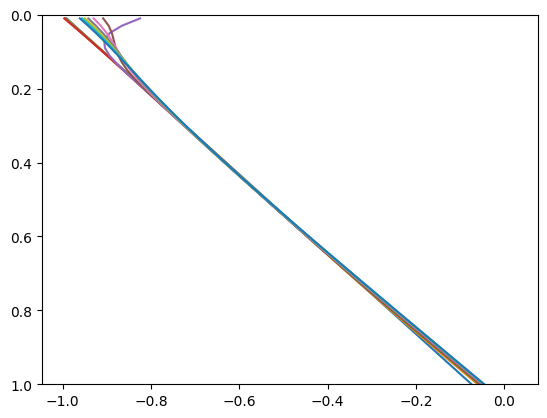

In [22]:
pl.plot(out.psie.T,sim.z)
pl.ylim(1,0)
pl.show()

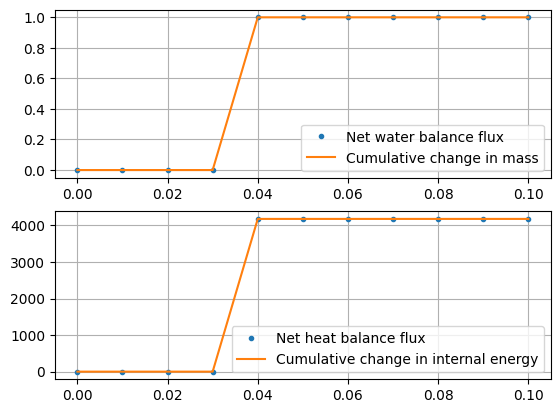

In [23]:
sim.plotBalance(out)